# Taller Semana 4 — Librerías de Python para Inteligencia Artificial

**Curso:** Fundamentos para IA (NRC 94103)
**Semana:** 4
**Docente:** [Nombre del docente]
**Estudiante(s):** [Nombre completo del estudiante]
**Fecha de entrega:** [dd/mm/aaaa]

**Dataset:** Netflix TV Shows and Movies — archivo `titles.csv` (Soeiro, 2022)

> Este cuaderno es un **ejemplo resuelto** del taller, explicado con palabras muy sencillas, ¡como si se lo contáramos a alguien de 10 años! Esta vez vamos a investigar las películas y series de Netflix: cuánto duran, qué calificación tienen y de qué tipo son.

## 1) Reconocimiento de frameworks de IA en Python

Imagina que quieres construir una casa con bloques de Lego.

- Una **librería** es como una cajita de piezas ya armadas (por ejemplo, una puerta ya hecha). La usas cuando la necesitas, dentro de lo que estás construyendo.
- Un **framework** es como el instructivo completo: te dice cómo debe organizarse toda la casa, y tú vas llenando los espacios con tus piezas.

Cuatro librerías/frameworks muy usados en Inteligencia Artificial:

- **Scikit-learn**: ayuda a la computadora a clasificar cosas o adivinar números (por ejemplo, "¿esta reseña es buena o mala?").
- **TensorFlow**: un framework de Google para enseñarle a la computadora cosas más difíciles, como reconocer caras en fotos.
- **PyTorch**: parecido a TensorFlow, muy usado por quienes investigan nuevas formas de inteligencia artificial.
- **Hugging Face**: se especializa en que la computadora entienda y escriba texto, como un chatbot.

Estas herramientas sirven para: clasificar cosas en grupos, predecir números, reconocer imágenes, entender texto, o agrupar cosas parecidas (esto último se llama clustering).

## 2) Selección y carga del dataset

Vamos a usar el archivo `titles.csv` del dataset de Netflix (Soeiro, 2022). Es como una ficha por cada película o serie: cuánto dura, de qué año es, qué calificación tiene, etc.

Fuente: https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
# Cargamos el archivo, como abrir un libro gigante de datos
df = pd.read_csv("../Semana_4_Actividad/titles.csv")
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


Cada fila es **una película o serie de Netflix**. Algunas columnas importantes son:

| Columna | Que significa |
|---|---|
| `title` | El nombre de la película o serie |
| `type` | Si es MOVIE (película) o SHOW (serie) |
| `release_year` | El año en que salió |
| `runtime` | Cuánto dura, en minutos |
| `genres` | Los géneros (comedia, drama, etc.) |
| `imdb_score` | La calificación que le dieron en IMDb |
| `imdb_votes` | Cuántas personas la calificaron |

In [3]:
# shape nos dice cuántas filas (títulos) y columnas (datos) hay
print("Filas y columnas:", df.shape)

# info() nos cuenta qué tipo de dato es cada columna: texto, número, etc.
df.info()

Filas y columnas: (5850, 15)
<class 'pandas.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   str    
 1   title                 5849 non-null   str    
 2   type                  5850 non-null   str    
 3   description           5832 non-null   str    
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   str    
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   str    
 8   production_countries  5850 non-null   str    
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   str    
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: 

`df.shape` es como contar cuántas fichas hay en una caja de fichas de juego: aquí hay 5.850 títulos y 15 columnas de datos sobre cada uno. `df.info()` nos dice, columna por columna, si guarda texto o números, y cuántos espacios NO están vacíos.

### Selección de 2 variables numéricas y 1 categórica

Para no analizar las 15 columnas a la vez, elegimos:

- `runtime` (numérica): cuánto dura el título, en minutos.
- `imdb_score` (numérica): la calificación que le dieron en IMDb.
- `type` (categórica): si es película o serie.

In [4]:
# Nos quedamos solo con las 3 columnas que vamos a analizar
df2 = df[['runtime', 'imdb_score', 'type']].copy()

# Buscamos espacios vacíos (nulos)
print("Valores vacíos por columna:")
print(df2.isnull().sum())
print("\nFilas repetidas:", df2.duplicated().sum())

Valores vacíos por columna:
runtime         0
imdb_score    482
type            0
dtype: int64

Filas repetidas: 2290


Encontramos 2.290 filas "repetidas" en esta tabla reducida de 3 columnas, pero no es un error: como solo dejamos runtime, imdb_score y type, es normal que muchos títulos distintos compartan, por pura coincidencia, la misma duración, la misma calificación y el mismo tipo (por ejemplo, dos películas distintas que ambas duran 90 minutos y tienen 6.5 de calificación). Cada fila sigue representando un título diferente en el archivo original, así que no eliminamos nada por esto. runtime y type no tienen ningún espacio vacío, pero imdb_score sí tiene bastantes: son títulos que todavía no han recibido suficientes votos en IMDb para tener una calificación.

In [5]:
# Rellenamos los espacios vacíos de imdb_score con la mediana
# (la mediana es mejor que el promedio aquí, porque no la mueven los casos extremos)
mediana_score = df2['imdb_score'].median()
df2['imdb_score'] = df2['imdb_score'].fillna(mediana_score)

# 'type' solo puede valer MOVIE o SHOW: se lo decimos a Python como categoría
df2['type'] = df2['type'].astype('category')

print(f"Rellenamos los espacios vacíos de imdb_score con la mediana: {mediana_score}")
print("\nValores vacíos después de la limpieza:")
print(df2.isnull().sum())

Rellenamos los espacios vacíos de imdb_score con la mediana: 6.6

Valores vacíos después de la limpieza:
runtime       0
imdb_score    0
type          0
dtype: int64


Decidimos **imputar** (rellenar) en vez de borrar esas filas, porque son casi 500 títulos: borrarlos nos haría perder muchísima información valiosa sobre duración y tipo de esos títulos.

### Tratamiento de valores atípicos (outliers)

¿Hay películas o series con una duración rarísima (mucho más larga que el resto)? Vamos a revisarlo con más cuidado en la sección de SciPy, usando una regla llamada z-score, y decidiremos si los conservamos o no.

## 3) Implementación con NumPy (cálculo y transformación)

NumPy es una librería súper veloz para hacer cuentas con muchísimos números a la vez, como una calculadora gigante que revisa todos los datos de un solo golpe (sin tener que ir uno por uno con un ciclo for).

In [6]:
# Acción 1: convertir la columna a un arreglo de NumPy
arr_runtime = np.array(df2['runtime'].values, dtype=float)
print(type(arr_runtime), arr_runtime.shape, arr_runtime[:10])

<class 'numpy.ndarray'> (5850,) [ 51. 114. 109.  91. 150.  30.  94. 102. 110. 104.]


Un **arreglo de NumPy** es como una fila de cajitas numeradas, todas guardando el mismo tipo de dato (números). Esto hace que las cuentas sean mucho más rápidas que con una lista normal de Python.

In [7]:
# Acción 2: media, mediana y percentiles
media = np.mean(arr_runtime)
mediana = np.median(arr_runtime)
percentiles = np.percentile(arr_runtime, [25, 50, 75])

print(f"Promedio de duración: {media:.2f} minutos")
print(f"La mitad de los títulos dura {mediana} minutos o menos (mediana)")
print(f"Percentil 25: {percentiles[0]} | Percentil 50: {percentiles[1]} | Percentil 75: {percentiles[2]}")

Promedio de duración: 76.89 minutos
La mitad de los títulos dura 83.0 minutos o menos (mediana)
Percentil 25: 44.0 | Percentil 50: 83.0 | Percentil 75: 104.0


- El **promedio** es como repartir en partes iguales: si sumáramos la duración de todos los títulos y la repartiéramos parejo, a cada uno le tocarían casi 77 minutos.
- La **mediana** es "el de en medio": si ponemos todos los títulos en fila de menor a mayor duración, este es el valor justo al centro.
- Los **percentiles** nos dicen en qué posición de la fila está cada título. Por ejemplo, el percentil 75 nos dice que el 75% de los títulos dura eso o menos.

In [8]:
# Acción 3: operación vectorizada (estandarización, sin usar ningún ciclo for)
z_runtime = (arr_runtime - arr_runtime.mean()) / arr_runtime.std()
print("Promedio del resultado (debe ser ~0):", round(z_runtime.mean(), 4))
print("Desviación del resultado (debe ser ~1):", round(z_runtime.std(), 4))
print("Cantidad de títulos con una duración MUY larga (z > 3):", int(np.sum(z_runtime > 3)))

Promedio del resultado (debe ser ~0): 0.0
Desviación del resultado (debe ser ~1): 1.0
Cantidad de títulos con una duración MUY larga (z > 3): 11


Esto se llama **vectorizar**: en vez de revisar título por título con un ciclo, le pedimos a NumPy que haga la resta y la división a los 5.850 títulos **a la vez**. Es mucho más rápido, como usar una fotocopiadora en vez de escribir a mano cada copia.

In [9]:
# Acción 4: contar cuántos títulos hay de cada tipo (sin usar Pandas, directo con NumPy)
valores, conteos = np.unique(df2['type'].to_numpy(), return_counts=True)
for v, c in zip(valores, conteos):
    print(f"{v}: {c} títulos ({c/len(df2)*100:.2f}%)")

MOVIE: 3744 títulos (64.00%)
SHOW: 2106 títulos (36.00%)


`np.unique` cuenta, de una sola vez, cuántas veces aparece cada valor distinto. Confirmamos que hay más películas que series en el catálogo.

## 4) Implementación con SciPy (análisis y estadística)

SciPy es una librería que sabe hacer "pruebas" matemáticas más avanzadas: por ejemplo, encontrar los valores más raros de un grupo, o comprobar si dos cosas están relacionadas de verdad (y no solo por casualidad).

In [10]:
# Procedimiento 1: z-score para encontrar los títulos con una duración atípica (muy fuera de lo común)
zscores_runtime = stats.zscore(df2['runtime'])
atipicos = df.loc[np.abs(zscores_runtime) > 3, ['title', 'type', 'runtime']]

print("Cantidad de títulos con una duración muy fuera de lo común:", len(atipicos))
atipicos.sort_values(by='runtime', ascending=False).head(10)

Cantidad de títulos con una duración muy fuera de lo común: 11


,title,type,runtime
923,Bonnie & Clyde,MOVIE,240
438,A Lion in the House,MOVIE,225
347,Lagaan: Once Upon a Time in India,MOVIE,224
412,Jodhaa Akbar,MOVIE,214
406,Kabhi Khushi Kabhie Gham,MOVIE,210
3076,The Irishman,MOVIE,209
351,No Direction Home: Bob Dylan,MOVIE,208
166,Hum Aapke Hain Koun..!,MOVIE,206
2495,Jab Harry Met Sejal,MOVIE,200
265,Apocalypse Now Redux,MOVIE,196


Encontramos títulos con una duración mucho más larga que el resto. Al mirar sus nombres, son películas o documentales épicos de verdad (dramas históricos larguísimos). **Decidimos conservarlos**: no son errores, son casos verdaderos que también forman parte del catálogo de Netflix.

In [11]:
# Procedimiento 2: correlación de Pearson entre duración e imdb_score
correlacion, p_valor = stats.pearsonr(df2['runtime'], df2['imdb_score'])

print(f"Correlación de Pearson: {correlacion:.4f}")
print(f"Valor p: {p_valor:.4e}")

if p_valor < 0.05:
    print("Sí existe una relación real (no es casualidad) entre la duración y la calificación.")
else:
    print("No hay evidencia de una relación real entre ambas variables.")

Correlación de Pearson: -0.1439
Valor p: 1.9437e-28
Sí existe una relación real (no es casualidad) entre la duración y la calificación.


La **correlación** nos dice si dos cosas se mueven juntas: un número cercano a **0** significa "casi no se relacionan", cercano a **1** significa "cuando una sube, la otra también sube mucho", y cercano a **-1** significa "cuando una sube, la otra baja". Aquí encontramos una relación negativa pero débil: los títulos más largos tienden a tener, en promedio, una calificación apenas un poquito más baja, pero la relación no es muy fuerte. El **valor p** nos dice qué tan seguros podemos estar de que esto no pasó por pura casualidad: como es muchísimo menor a 0.05, sí confiamos en el resultado.

## 5) Visualización con Matplotlib (mínimo 3 gráficas)

Ahora vamos a **dibujar** lo que encontramos, para verlo con los ojos y no solo con números. Matplotlib es como una caja de lápices y reglas: nos deja dibujar exactamente lo que queramos, pero paso a paso.

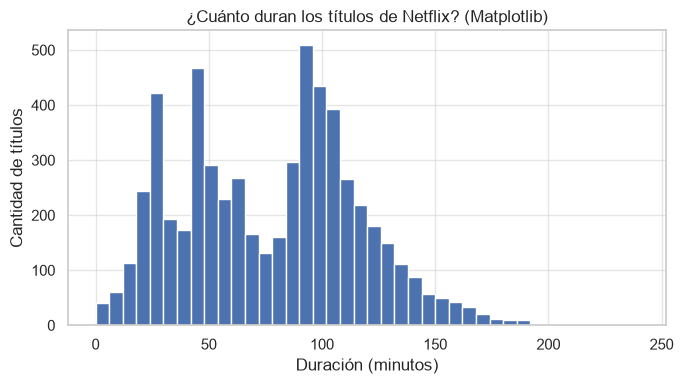

In [12]:
# Gráfica 1: histograma — ¿cuánto duran los títulos?
plt.figure(figsize=(7, 4))
plt.hist(df2['runtime'], bins=40, color="#4C72B0", edgecolor="white")
plt.title("¿Cuánto duran los títulos de Netflix? (Matplotlib)")
plt.xlabel("Duración (minutos)")
plt.ylabel("Cantidad de títulos")
plt.tight_layout()
plt.show()

Un **histograma** es como agrupar canicas por tamaño en distintas cajas y ver cuál caja tiene más canicas. Aquí vemos dos "montoncitos": uno cerca de los 30-50 minutos (episodios de series) y otro más grande cerca de los 90-100 minutos (películas).

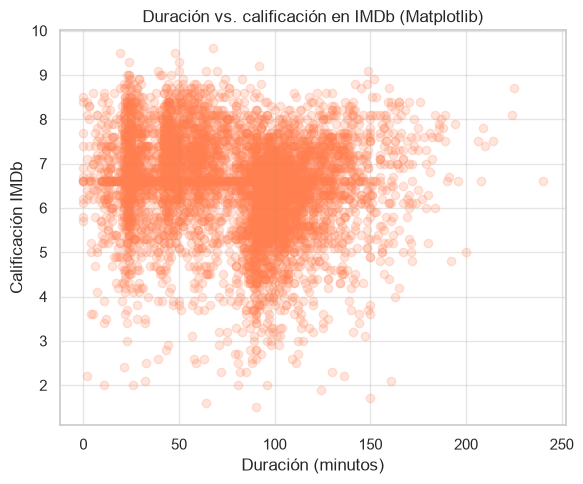

In [13]:
# Gráfica 2: dispersión — duración vs. calificación
plt.figure(figsize=(6, 5))
plt.scatter(df2['runtime'], df2['imdb_score'], alpha=0.2, color="coral")
plt.title("Duración vs. calificación en IMDb (Matplotlib)")
plt.xlabel("Duración (minutos)")
plt.ylabel("Calificación IMDb")
plt.tight_layout()
plt.show()

Un **gráfico de dispersión** pone un puntito por cada título, según cuánto dura y qué calificación tiene. Si los puntos formaran una línea clara, significaría que van muy de la mano; aquí la nube de puntos es bastante ancha, lo que coincide con la correlación débil que calculamos con SciPy.

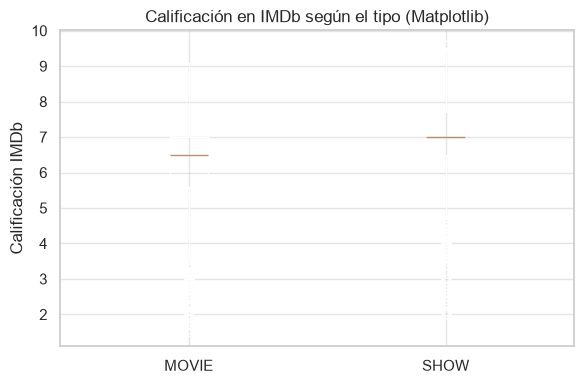

In [14]:
# Gráfica 3: diagrama de caja — calificación según el tipo de título
peliculas = df2[df2['type'] == 'MOVIE']['imdb_score']
series = df2[df2['type'] == 'SHOW']['imdb_score']

plt.figure(figsize=(6, 4))
plt.boxplot([peliculas, series], tick_labels=["MOVIE", "SHOW"])
plt.title("Calificación en IMDb según el tipo (Matplotlib)")
plt.ylabel("Calificación IMDb")
plt.tight_layout()
plt.show()

Un **diagrama de caja** (*boxplot*) muestra dónde está la mayoría de los datos (la cajita), el valor de en medio (la línea) y los casos raros (los puntitos sueltos, títulos con calificaciones muy altas o muy bajas). Aquí vemos que películas y series tienen calificaciones bastante parecidas.

## 6) Visualización con Seaborn (mínimo 3 gráficas)

Seaborn está construido encima de Matplotlib, pero ya viene con dibujos estadísticos "prearmados" y más bonitos por defecto: es como tener moldes de repostería en vez de cortar la masa a mano.

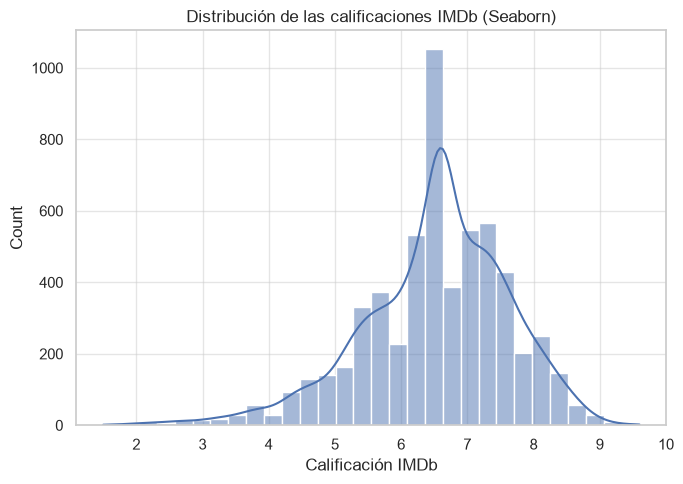

In [15]:
# Gráfica 1: histograma con curva de densidad
plt.figure(figsize=(7, 5))
sns.histplot(df2['imdb_score'], bins=30, kde=True, color="#4C72B0")
plt.title("Distribución de las calificaciones IMDb (Seaborn)")
plt.xlabel("Calificación IMDb")
plt.tight_layout()
plt.show()

`sns.histplot` con `kde=True` dibuja el mismo histograma que antes, pero además agrega una línea suave (la curva de densidad) que muestra la forma general de la distribución, sin que tengamos que calcularla nosotros mismos.

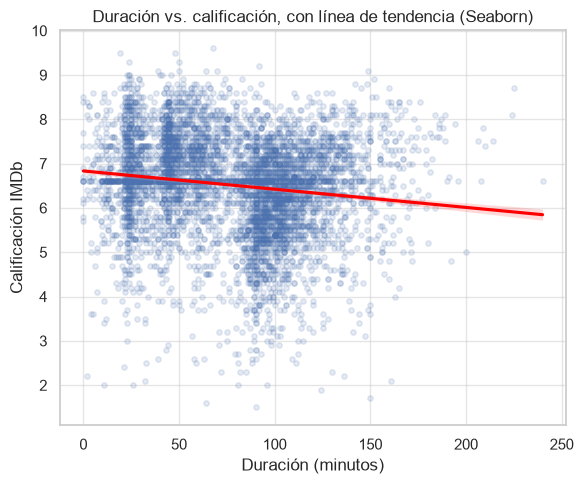

In [16]:
# Gráfica 2: dispersión con línea de tendencia
plt.figure(figsize=(6, 5))
sns.regplot(x='runtime', y='imdb_score', data=df2,
            scatter_kws={"alpha": 0.15, "s": 15}, line_kws={"color": "red"})
plt.title("Duración vs. calificación, con línea de tendencia (Seaborn)")
plt.xlabel("Duración (minutos)")
plt.ylabel("Calificación IMDb")
plt.tight_layout()
plt.show()

`sns.regplot` dibuja los mismos puntos que antes, pero además calcula y dibuja **solita** la línea de tendencia (la línea roja). Con Matplotlib puro tendríamos que calcular esa línea nosotros mismos con una fórmula aparte.

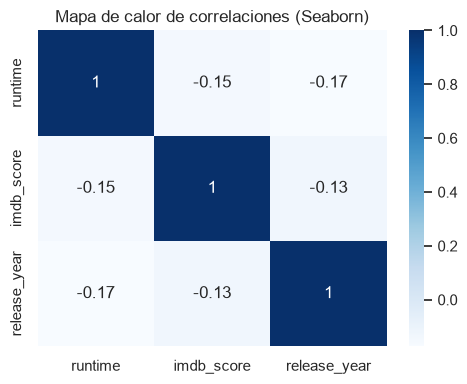

In [17]:
# Gráfica 3: mapa de calor de correlaciones
plt.figure(figsize=(5, 4))
correlaciones = df[['runtime', 'imdb_score', 'release_year']].corr()
sns.heatmap(correlaciones, annot=True, cmap="Blues")
plt.title("Mapa de calor de correlaciones (Seaborn)")
plt.tight_layout()
plt.show()

Un **mapa de calor** (*heatmap*) es como un cuadro de colores: entre más oscuro (más cerca de 1), más se parecen los movimientos de esas dos variables. Vemos que `runtime` e `imdb_score` tienen una relación débil (como ya sabíamos), y que `release_year` tampoco está muy relacionado con la calificación.

**Comparación Matplotlib vs. Seaborn (ejemplo de este taller):** para el diagrama de caja de la sección anterior, con Matplotlib tuvimos que separar nosotros mismos los datos en dos listas (`peliculas` y `series`) antes de graficar. Con `sns.regplot`, en cambio, Seaborn calculó y dibujó la línea de tendencia automáticamente, sin que tuviéramos que hacer ninguna cuenta extra.

## 7) Pensamiento crítico

**¿Cuándo conviene usar Matplotlib y cuándo Seaborn?**

Matplotlib conviene cuando queremos controlar cada detalle del dibujo, paso a paso (como en nuestro histograma o boxplot). Seaborn conviene cuando queremos un gráfico estadístico bonito y completo en una sola línea, como el `regplot` que dibujó solo la línea de tendencia entre duración y calificación.

**¿Qué ventajas aporta NumPy frente a trabajar solo con Pandas?**

NumPy hace las cuentas mucho más rápido porque trabaja con arreglos de números "puros" en la memoria de la computadora, sin toda la información extra que carga una tabla de Pandas. Por eso pudimos calcular la media, la mediana y la estandarización de 5.850 títulos de golpe, sin ningún ciclo for.

**¿Qué aportó SciPy que no era tan directo con NumPy/Pandas?**

SciPy nos dio pruebas ya armadas, como el z-score para encontrar valores atípicos y la correlación de Pearson con su valor p. Con NumPy o Pandas solos, tendríamos que calcular esas fórmulas estadísticas nosotros mismos, paso por paso.

**Si el objetivo fuera construir un modelo de IA (predicción), ¿qué herramienta sumarían y por qué?**

Sumaríamos **Scikit-learn**, porque ya viene con algoritmos listos para, por ejemplo, predecir la calificación de un título según su duración, año y tipo, sin tener que programar esas fórmulas desde cero.

**¿Qué limitaciones detectaron en su dataset para aplicar análisis estadístico o visual?**

Encontramos bastantes valores nulos en `imdb_score` (títulos sin suficientes votos todavía), que tuvimos que imputar con la mediana. Además, la duración (`runtime`) mezcla películas y episodios de series, que no siempre son comparables entre sí.

## Preguntas del caso

**¿Qué fenómeno, proceso o contexto representa el dataset?**

Representa el catálogo de películas y series disponibles en Netflix: su duración, año de estreno, tipo de contenido y qué tan bien calificadas están por el público.

**¿Cuáles son las 5 variables más importantes para describir el caso y por qué?**

1. **`type`**: distingue si es película o serie, algo fundamental porque el consumo de cada una es muy distinto.
2. **`runtime`**: la duración, clave para saber cuánto tiempo pasa un usuario viendo ese título.
3. **`imdb_score`**: la calificación, el indicador principal de qué tan buena es la producción según el público.
4. **`release_year`**: el año de estreno, útil para ver tendencias del catálogo a través del tiempo.
5. **`genres`**: el género, importante para entender qué tipo de historias ofrece Netflix y para sistemas de recomendación.

**¿Qué hallazgos se observan en la distribución de variables (categóricas y numéricas)?**

En la variable categórica `type`, hay más películas que series en el catálogo. En las variables numéricas, `runtime` tiene una forma con dos "montoncitos" (uno para episodios de series, más cortos, y otro para películas, más largos), y `imdb_score` se concentra en su mayoría entre 5 y 8 puntos.

**¿Qué relación relevante encontraron entre las variables?**

- `runtime` e `imdb_score` tienen una correlación negativa pero débil: los títulos más largos tienden a tener, en promedio, una calificación apenas un poco más baja.
- Al revisar el mapa de calor, `release_year` no muestra una relación fuerte con `imdb_score`: los títulos más nuevos no son necesariamente mejor ni peor calificados que los más viejos.

**¿Qué problemas de calidad de datos detectaron y cómo los abordan?**

Encontramos muchos valores nulos en `imdb_score` (títulos sin suficientes votos), que se imputaron con la mediana para no perder esos títulos ni sesgar la calificación promedio. También detectamos títulos con una duración extremadamente larga, que decidimos conservar por ser casos reales (películas y documentales épicos).

**Con base en lo observado, ¿qué pregunta de IA o problema predictivo podría plantearse a futuro con este dataset?**

Se podría plantear un problema de **regresión**: predecir la calificación de IMDb de un título nuevo a partir de su duración, año y género. También un problema de **clasificación** para predecir si un contenido nuevo será película o serie según sus características.

## Bibliografía

Boschetti, A. y Massaron, L. (2018). *Python Data Science Essentials: A Practitioner's Guide Covering Essential Data Science Principles, Tools, and Techniques* (pp. 281-331). Packt Publishing Ltd.

Yim, A., Chung, C., & Yu, A. (2018). *Matplotlib for Python Developers: Effective Techniques for Data Visualization with Python* (2nd ed., pp. 21-54). Packt Publishing, Limited.

Fuentes, A. (2018). *Become a Python Data Analyst: Perform Exploratory Data Analysis and Gain Insight into Scientific Computing Using Python* (pp. 69-118). Packt Publishing, Limited.

Mehta, H. (2015). *Mastering Python Scientific Computing* (pp. 163-198). Packt Publishing, Limited.

Soeiro, V. (2022). *Netflix TV Shows and Movies* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies